In [36]:
from datasets import load_dataset
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import random
from collections import Counter
import torch
import kagglehub
import os

from topology import create_topology
from split_data import split_data
from agent import Agent
from save_results import save_results_to_pickle
from FL import train_dpsgd, train_pame
from model import TwoLayerNN, OkanNet
from simulate_network import NetworkConditions
from plot import colors, visualize_agents_distribution, visualize_dataset_classes

In [3]:
def train_with_configuration(global_model=None, algorithm_key='gossip', num_agents=10, 
                             topology_key='circle', learning_rate=0.5, coeff_lr = 0.99, num_rounds=5, degree=2, 
                             return_all_metrics=False, verbose=True, communication_period=1,
                             train_dataset = None, test_dataset = None, distribution_type='iid', 
                             steps_per_round = 1, client_fraction = 1.0, 
                             gossip_strategy='all', batch_size=64, fix_learning_rate=False, alpha=0.5,
                             network_config=None, random_seed=42, eval_every=1, scheduled_dropouts=None, return_agent_metrics=False,
                             sparsification_rate=0.2, participation_rate=1, sigma_0=0.5, gamma=1.001,
                             initial_weights_flag = False):
    """
    Функция для обучения
    """
    topology = create_topology(num_agents, degree, random_seed)
    agent_datasets = split_data(train_dataset, num_agents, distribution_type, alpha, random_seed, verbose)
    
    agent_distribution_info = []
    for i, subset in enumerate(agent_datasets):
        indices = subset.indices
        labels = [train_dataset[idx][1] for idx in indices]
        class_counts = Counter(labels)
        agent_distribution_info.append({'agent_id': i, 'num_samples': len(indices), 'class_distribution': dict(class_counts)})

    if torch.cuda.is_available():
        device = 'cuda'
    elif torch.backends.mps.is_available():
        device = 'mps'
    else:
        device = 'cpu'

    agents = []
    for i, dataset in enumerate(agent_datasets):
        unique_seed = random_seed * 1000 + i
        torch.manual_seed(unique_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(unique_seed)
        data = [(dataset[j][0], dataset[j][1]) for j in range(len(dataset))]
        
        agent = Agent(data, i, global_model, steps_per_round, batch_size, device, unique_seed)
        agents.append(agent)

    if initial_weights_flag == True:

        zero_weights = agents[0].get_weights()
        for agent in agents[1:]:
            agent.set_weights(zero_weights)
    
    if verbose:
        print(f"Создано {len(agents)} агентов с распределением '{distribution_type}'")
        print(f"Используемое устройство: {device}")
    
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) if test_dataset else None
    
    network_conditions = None
    if network_config is not None:
        if isinstance(network_config, NetworkConditions):
            network_conditions = network_config
        elif isinstance(network_config, dict) and len(network_config) > 0:
            network_conditions = NetworkConditions(**network_config)
            if scheduled_dropouts:
                network_conditions.scheduled_dropouts = scheduled_dropouts
    
    
    if algorithm_key == 'pame':
        model, metric_dic = train_pame(
            agents, topology, num_rounds, gossip_strategy, 
            network_conditions, random_seed,
            test_loader, global_model, return_all_metrics, eval_every,
            verbose, return_agent_metrics, communication_period,
            sparsification_rate, participation_rate, sigma_0, gamma
        )
    elif algorithm_key == 'dpsgd':
        model, metric_dic = train_dpsgd(
            agents, topology, learning_rate, coeff_lr, num_rounds, gossip_strategy, 
            network_conditions, random_seed, 
            test_loader, global_model, return_all_metrics, eval_every, 
            fix_learning_rate, verbose, return_agent_metrics, communication_period
        )
    
    else:
        raise ValueError(f"Неизвестный алгоритм: {algorithm_key}")

    run_params = {
        'algo_name': algorithm_key,
        'algo_topology': topology_key,
        'train_steps_per_round': steps_per_round,
        'sys_num_agents': num_agents,
        'sys_num_rounds': num_rounds,
        'sys_degree': degree if topology_key in ['mesh', 'circle'] else None,
        'data_model': model,
        'data_distribution': distribution_type,
        'data_agent_dist': agent_distribution_info,
        'data_network_config': network_config,
        'seed': random_seed
    }

    algo_spec = {}

    if algorithm_key == 'fedavg':
        algo_spec['client_fraction'] = client_fraction
        algo_spec['train_lr'] = learning_rate
        algo_spec['train_coeff_lr'] = coeff_lr
        algo_spec['train_fix_lr'] = fix_learning_rate

    elif algorithm_key == 'dpsgd':
        algo_spec['gossip_strategy'] = gossip_strategy
        algo_spec['communication_period'] = communication_period
        algo_spec['train_lr'] = learning_rate
        algo_spec['train_coeff_lr'] = coeff_lr
        algo_spec['train_fix_lr'] = fix_learning_rate

    elif algorithm_key == 'pame':
        algo_spec['gossip_strategy'] = gossip_strategy
        algo_spec['sparsification_rate'] = sparsification_rate
        algo_spec['participation_rate'] = participation_rate
        algo_spec['sigma_0'] = sigma_0
        algo_spec['gamma'] = gamma
        algo_spec['communication_period'] = communication_period

    run_params['algo_spec'] = algo_spec

    return {
        'metric_dic': metric_dic,
        'run_params': run_params
    }

In [4]:
def run_network_experiment(algorithm_key, num_agents=12, num_rounds=100,
    train_dataset=None, test_dataset=None,
    packet_loss_rate=0.0, noise_std=0.0, node_dropout_prob=0.0, fix_learning_rate=False,
    dropout_rounds_min=1, dropout_rounds_max=3, delay_min=0, delay_max=0, delay_probability=0,
    dropout_stops_training=True, scheduled_dropouts=None, communication_period=1, topology_key='circle',
    gossip_strategy='all', verbose=True, global_model=None,
    random_seed=42, save_results=True, custom_filename=None, degree=4, base_dir='results_MNIST',
    return_all_metrics=False,distribution_type='iid', learning_rate=0.5, coeff_lr=0.99,
    sparsification_rate=0.2, participation_rate=0.5, sigma_0=5, gamma=1.001,
    initial_weights_flag = False, steps_per_round=1, batch_size=128):
    
    network_config = NetworkConditions(
        packet_loss_rate=packet_loss_rate,
        noise_std=noise_std,
        node_dropout_prob=node_dropout_prob,
        dropout_rounds_min=dropout_rounds_min,
        dropout_rounds_max=dropout_rounds_max,
        dropout_stops_training=dropout_stops_training,
        scheduled_dropouts=scheduled_dropouts or [],
        random_seed=random_seed,
        delay_min=delay_min,
        delay_max=delay_max,
        delay_probability=delay_probability
    )

    if algorithm_key == 'pame':
        print(sparsification_rate, participation_rate, sigma_0, gamma, initial_weights_flag)
        result = train_with_configuration(
            global_model=global_model,
            algorithm_key=algorithm_key,
            num_agents=num_agents,
            topology_key=topology_key,
            degree=degree,
            num_rounds=num_rounds,
            gossip_strategy=gossip_strategy,
            train_dataset=train_dataset,
            test_dataset=test_dataset,
            distribution_type=distribution_type,
            verbose=verbose,
            network_config=network_config,
            random_seed=random_seed,
            communication_period=communication_period,
            return_all_metrics=return_all_metrics,
            sparsification_rate=sparsification_rate,
            participation_rate=participation_rate,
            sigma_0=sigma_0,
            gamma=gamma,
            initial_weights_flag = initial_weights_flag,
            steps_per_round=steps_per_round,
            batch_size=batch_size
        )
    else:
        print(learning_rate, coeff_lr, fix_learning_rate, initial_weights_flag)
        result = train_with_configuration(
            global_model=global_model,
            algorithm_key=algorithm_key,
            num_agents=num_agents,
            topology_key=topology_key,
            learning_rate=learning_rate,
            coeff_lr=coeff_lr,
            degree=degree,
            num_rounds=num_rounds,
            gossip_strategy=gossip_strategy,
            train_dataset=train_dataset,
            test_dataset=test_dataset,
            distribution_type=distribution_type,
            verbose=verbose,
            network_config=network_config,
            random_seed=random_seed,
            communication_period=communication_period,
            return_all_metrics=return_all_metrics,
            fix_learning_rate=fix_learning_rate,
            initial_weights_flag = initial_weights_flag,
            steps_per_round=steps_per_round,
            batch_size=batch_size
        )

    
    print(f"[{algorithm_key.upper()}] Acc={result['metric_dic']['accuracy'][-1]:.4f}, Acc_active={result['metric_dic']['accuracy_active'][-1]:.4f}, "
            f"Loss={result['metric_dic']['loss'][-1]:.4f}, Loss_active={result['metric_dic']['loss_active'][-1]:.4f}, " 
            f"Consensus={result['metric_dic']['consensus_error'][-1]:.6f}, Consensus_active={result['metric_dic']['consensus_error_active'][-1]:.6f}")

    
    if save_results:
        filepath = save_results_to_pickle(result, base_dir=base_dir, custom_filename=custom_filename)
        result['saved_path'] = filepath
    
    return result

## MNIST

In [13]:
ds = load_dataset("ylecun/mnist", cache_dir="./data/MNIST")

def calculate_mean_std(dataset):
    total_sum = 0
    total_squared_sum = 0
    total_pixels = 0
    
    for item in dataset:
        image = np.array(item['image'])
        image_normalized = image.astype(np.float32) / 255.0
        pixels = image_normalized.flatten()
        total_sum += np.sum(pixels)
        total_squared_sum += np.sum(pixels ** 2)
        total_pixels += len(pixels)
    mean = total_sum / total_pixels
    variance = (total_squared_sum / total_pixels) - (mean ** 2)
    std = np.sqrt(variance)
    
    return mean, std

train_mean, train_std = calculate_mean_std(ds['train'])
print(f"Training - Mean: {train_mean:.4f}, Std: {train_std:.4f}")
test_mean, test_std = calculate_mean_std(ds['test'])
print(f"Test - Mean: {test_mean:.4f}, Std: {test_std:.4f}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((train_mean,), (train_std,))
])

class MNISTDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image']
        label = item['label']
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

train_dataset = MNISTDataset(ds['train'], transform=transform)
test_dataset = MNISTDataset(ds['test'], transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Training - Mean: 0.1307, Std: 0.3081
Test - Mean: 0.1325, Std: 0.3105


### Распределение данных - Пример

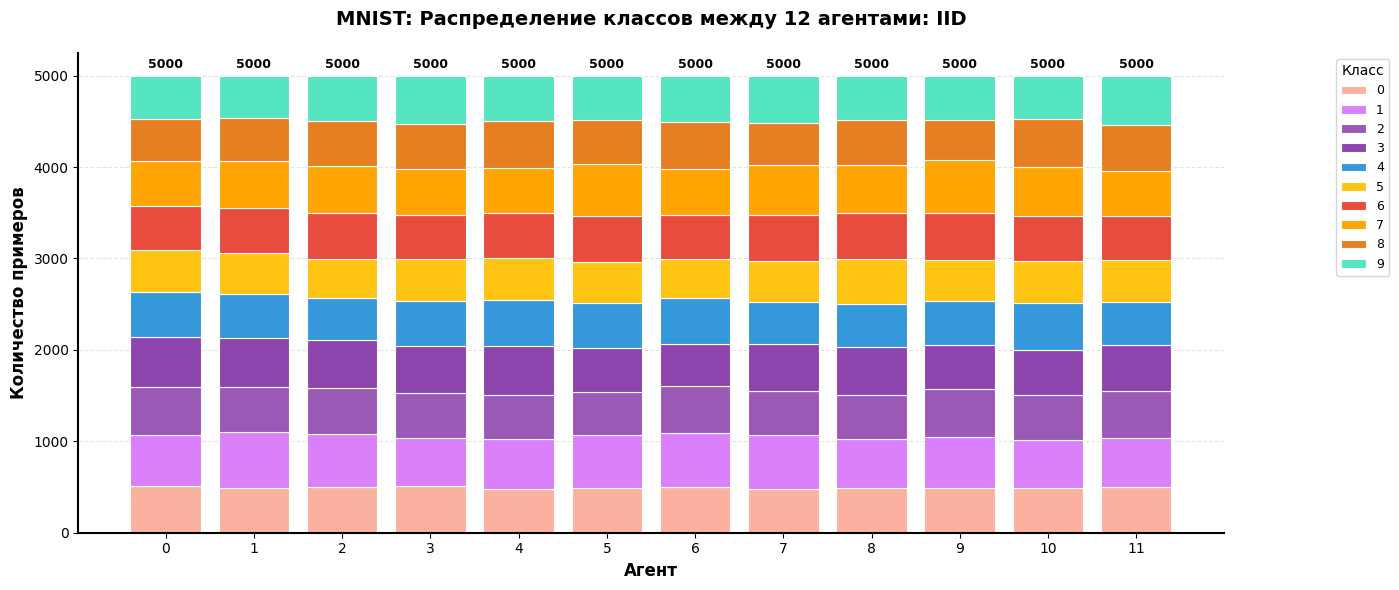

In [20]:
random.shuffle(colors)
visualize_agents_distribution(train_dataset, num_agents=12, distribution='iid', colors=colors, title_prefix="MNIST: ")

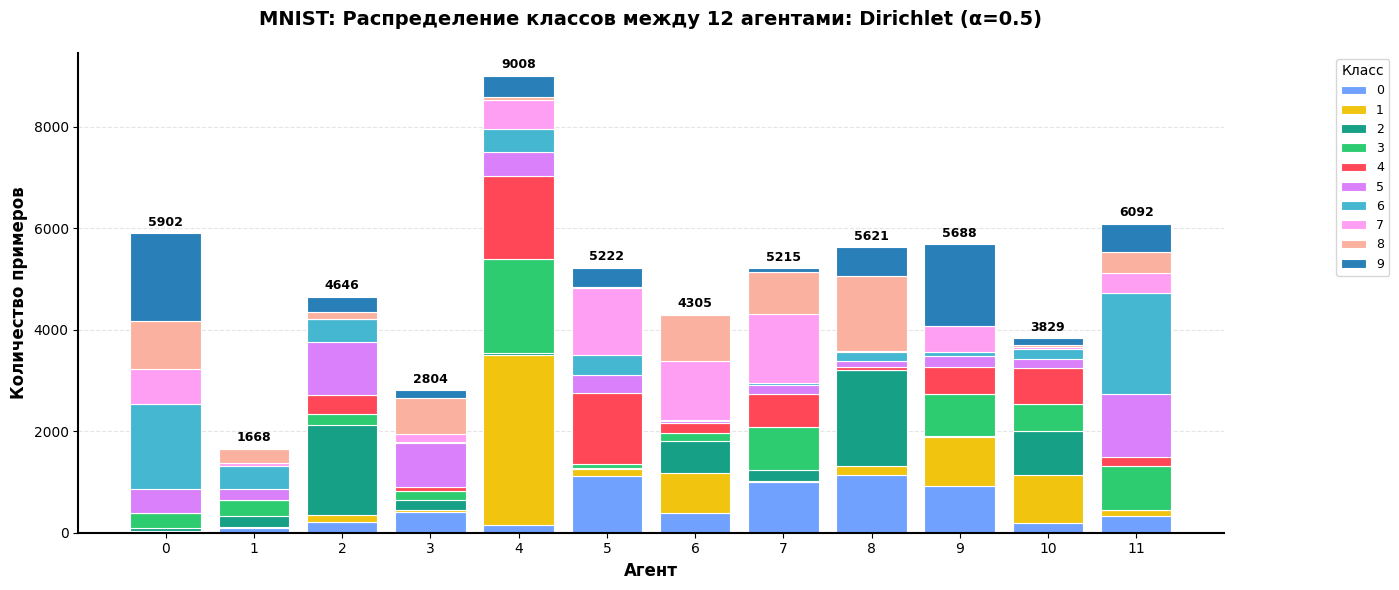

In [21]:
random.shuffle(colors)
visualize_agents_distribution(train_dataset, num_agents=12, distribution='dirichlet', colors=colors, title_prefix="MNIST: ")

### Структура данных

Найдено классов: 10
Названия классов: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


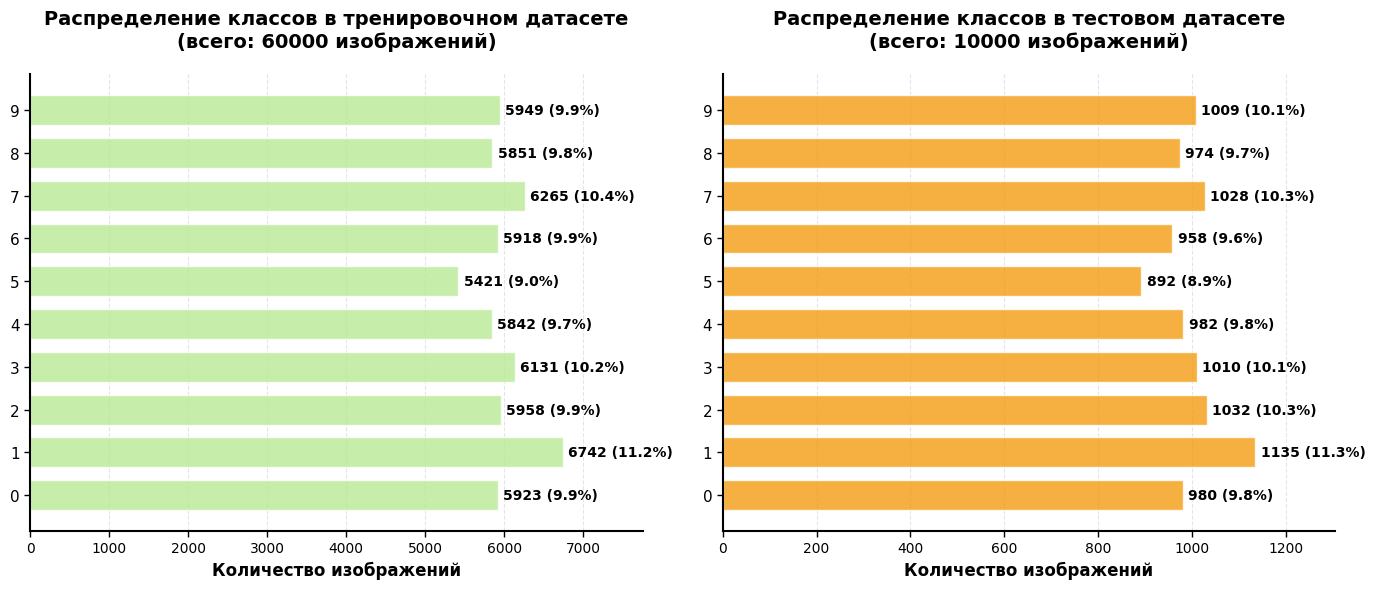

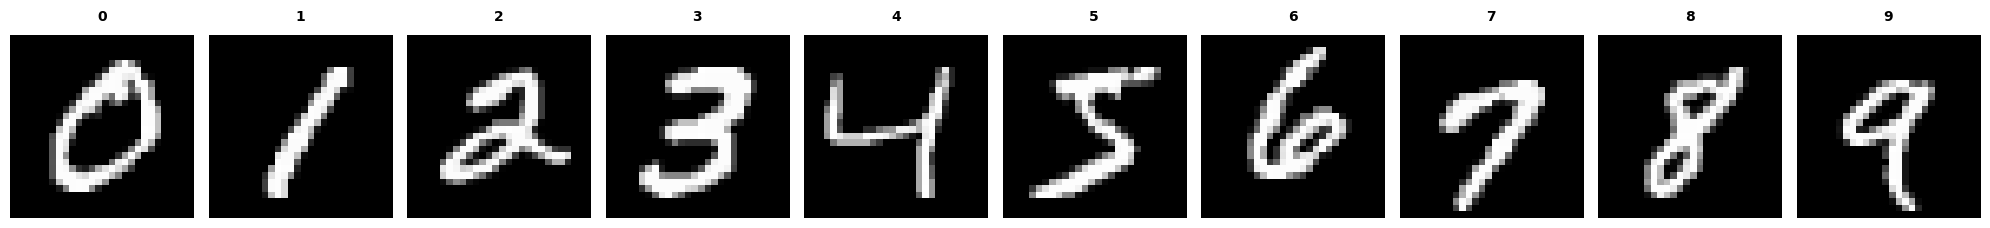


Соотношение (макс/мин): 1.24
Классы сбалансированы!


In [24]:
visualize_dataset_classes([random.choice(colors), random.choice(colors)], train_dataset, test_dataset, train_mean, train_std)

In [ ]:
N_RUNS = 25

base_config = {
    'packet_loss_rate': 0.0,
    'noise_std': 0.0,
    'node_dropout_prob': 0.0,
    'dropout_rounds_min': 1,
    'dropout_rounds_max': 5,
    'delay_min': 0,
    'delay_max': 0,
    'delay_probability': 0.0,
}

def make_config(name, **kwargs):
    config = base_config.copy()
    config['name'] = name
    config.update(kwargs)
    return config

network_configs = [
    make_config('ideal'),
    # make_config('loss_10', packet_loss_rate=0.1),
    # make_config('loss_30', packet_loss_rate=0.3),
    # make_config('loss_50', packet_loss_rate=0.5),
    # make_config('noise_0.005', noise_std=0.005),
    # make_config('noise_0.01', noise_std=0.01),
    # make_config('auto_dropout_10_stop_1-10', node_dropout_prob=0.1, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=True),
    # make_config('auto_dropout_10_continue_1-10', node_dropout_prob=0.1, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=False),
    # make_config('auto_dropout_30_stop_1-10', node_dropout_prob=0.3, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=True),
    # make_config('auto_dropout_30_continue_1-10', node_dropout_prob=0.3, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=False),
    # make_config('delay_1_5_0.1', delay_min=1, delay_max=5, delay_probability=0.1),
    # make_config('delay_1_5_0.3', delay_min=1, delay_max=5, delay_probability=0.3),
    # make_config('delay_6_10_0.1', delay_min=6, delay_max=10, delay_probability=0.1),
    # make_config('delay_6_10_0.3', delay_min=6, delay_max=10, delay_probability=0.3),
]

experiment_results = {cfg['name']: [] for cfg in network_configs}

for cfg in network_configs:
    config_name = cfg['name']
    
    for i in range(N_RUNS):
        seed = 4200 + i
        
        print(f"\n>>> Запуск {i+1}/{N_RUNS} (config={config_name}, seed={seed})")
        
        try:
            result = run_network_experiment(
                algorithm_key='dpsgd',
                num_rounds=10,
                train_dataset=train_dataset,
                test_dataset=test_dataset,
                packet_loss_rate=cfg['packet_loss_rate'],
                noise_std=cfg['noise_std'],
                node_dropout_prob=cfg['node_dropout_prob'],
                dropout_rounds_min=cfg['dropout_rounds_min'],
                dropout_rounds_max=cfg['dropout_rounds_max'],
                dropout_stops_training=cfg.get('dropout_stops_training', False),
                delay_min=cfg['delay_min'],
                delay_max=cfg['delay_max'],
                delay_probability=cfg['delay_probability'],
                scheduled_dropouts=cfg.get('scheduled_dropouts', None),
                verbose=True,
                global_model=TwoLayerNN,
                topology_key='mesh',
                random_seed=seed,
                num_agents=12,
                degree=2,
                return_all_metrics=True,
                distribution_type='iid',
                base_dir='results_MNIST',
                fix_learning_rate=False,
                initial_weights_flag=False,
                batch_size=64,
                learning_rate=0.5, 
                coeff_lr=0.99
                
            )
            
            experiment_results[config_name].append(result)
            print(f"Acc={result['metric_dic']['accuracy'][-1]:.4f}")
            
        except Exception as e:
            print(f"Ошибка: {e}")
            experiment_results[config_name].append(None)

In [ ]:
N_RUNS = 25

base_config = {
    'packet_loss_rate': 0.0,
    'noise_std': 0.0,
    'node_dropout_prob': 0.0,
    'dropout_rounds_min': 1,
    'dropout_rounds_max': 5,
    'delay_min': 0,
    'delay_max': 0,
    'delay_probability': 0.0,
}

def make_config(name, **kwargs):
    config = base_config.copy()
    config['name'] = name
    config.update(kwargs)
    return config

network_configs = [
    # make_config('ideal'),
    # make_config('loss_10', packet_loss_rate=0.1),
    # make_config('loss_30', packet_loss_rate=0.3),
    make_config('loss_50', packet_loss_rate=0.5),
    # make_config('noise_0.005', noise_std=0.005),
    # make_config('noise_0.01', noise_std=0.01),
    # make_config('auto_dropout_10_stop_1-10', node_dropout_prob=0.1, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=True),
    # make_config('auto_dropout_10_continue_1-10', node_dropout_prob=0.1, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=False),
    # make_config('auto_dropout_30_stop_1-10', node_dropout_prob=0.3, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=True),
    # make_config('auto_dropout_30_continue_1-10', node_dropout_prob=0.3, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=False),
    # make_config('delay_1_5_0.1', delay_min=1, delay_max=5, delay_probability=0.1),
    # make_config('delay_1_5_0.3', delay_min=1, delay_max=5, delay_probability=0.3),
    # make_config('delay_6_10_0.1', delay_min=6, delay_max=10, delay_probability=0.1),
    # make_config('delay_6_10_0.3', delay_min=6, delay_max=10, delay_probability=0.3),
]

experiment_results = {cfg['name']: [] for cfg in network_configs}

for cfg in network_configs:
    config_name = cfg['name']
    
    for i in range(N_RUNS):
        seed = 42 + i
        
        print(f"\n>>> Запуск {i+1}/{N_RUNS} (config={config_name}, seed={seed})")
        
        try:
            result = run_network_experiment(
                algorithm_key='pame',
                num_rounds=100,
                train_dataset=train_dataset,
                test_dataset=test_dataset,
                packet_loss_rate=cfg['packet_loss_rate'],
                noise_std=cfg['noise_std'],
                node_dropout_prob=cfg['node_dropout_prob'],
                dropout_rounds_min=cfg['dropout_rounds_min'],
                dropout_rounds_max=cfg['dropout_rounds_max'],
                dropout_stops_training=cfg.get('dropout_stops_training', False),
                delay_min=cfg['delay_min'],
                delay_max=cfg['delay_max'],
                delay_probability=cfg['delay_probability'],
                scheduled_dropouts=cfg.get('scheduled_dropouts', None),
                verbose=True,
                global_model=TwoLayerNN,
                topology_key='mesh',
                random_seed=seed,
                num_agents=12,
                degree=2,
                return_all_metrics=True,
                distribution_type='dirichlet',
                base_dir='results_MNIST',
                fix_learning_rate=False,
                initial_weights_flag=False,
                batch_size=64,
                sparsification_rate=0.2, 
                participation_rate=0.5, 
                sigma_0=5, 
                gamma=1.001
                
            )
            
            experiment_results[config_name].append(result)
            print(f" Acc={result['metric_dic']['accuracy'][-1]:.4f}")
            
        except Exception as e:
            print(f" Ошибка: {e}")
            experiment_results[config_name].append(None)

## **Brain Tumor MRI Dataset**

In [38]:
def compute_dataset_stats(dataset_path, batch_size=64):
    temp_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
    ])
    
    temp_dataset = datasets.ImageFolder(root=dataset_path, transform=temp_transform)
    temp_loader = DataLoader(temp_dataset, batch_size=batch_size, shuffle=False)
    
    channels_sum = 0
    channels_squared_sum = 0
    total_samples = 0
    
    for images, _ in temp_loader:
        batch_samples = images.size(0)
        channels_sum += torch.mean(images, dim=[0, 2, 3]) * batch_samples
        channels_squared_sum += torch.mean(images ** 2, dim=[0, 2, 3]) * batch_samples
        total_samples += batch_samples
    
    mean = (channels_sum / total_samples).numpy()[0]
    std = torch.sqrt((channels_squared_sum / total_samples) - (channels_sum / total_samples) ** 2).numpy()[0]
    
    print(f"Training - Mean: {mean:.4f}")
    print(f"Training - Std: {std:.4f}")
    
    return mean, std

In [39]:
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
#print("Путь к датасету:", path)

train_path = os.path.join(path, "Training")
test_path = os.path.join(path, "Testing")

mean_val, std_val = compute_dataset_stats(train_path)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean_val], std=[std_val])
])


train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Training - Mean: 0.1840
Training - Std: 0.1933


### Распределение данных - Пример

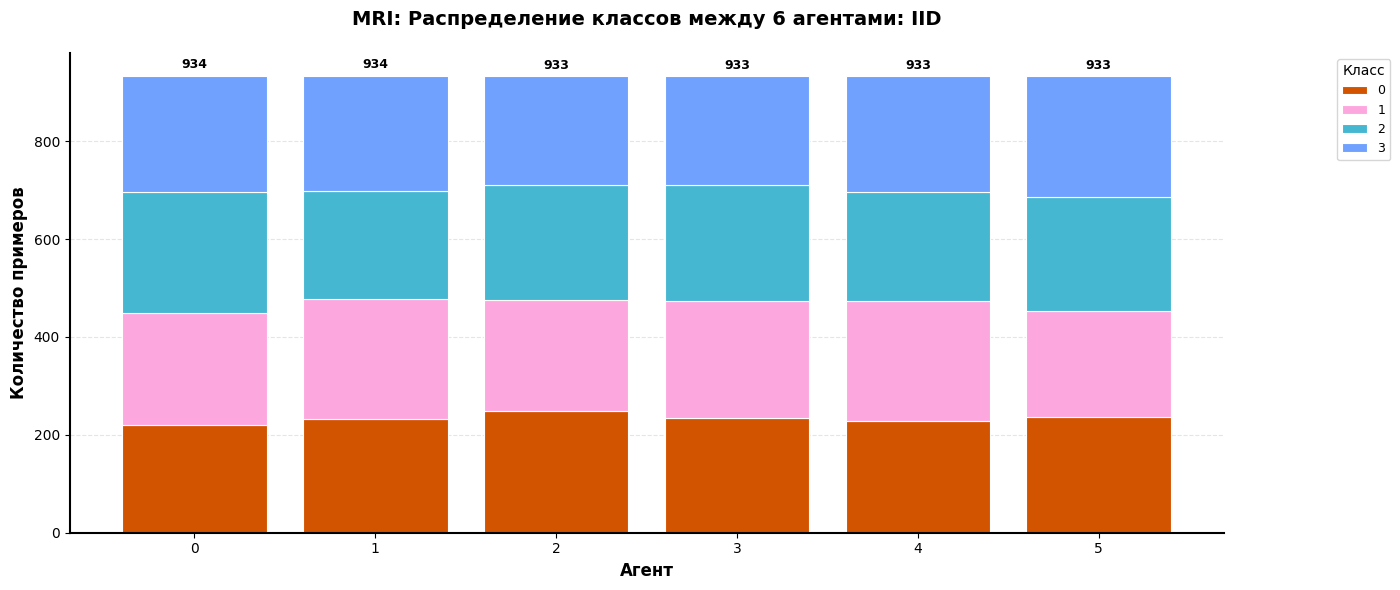

In [43]:
random.shuffle(colors)
visualize_agents_distribution(train_dataset, num_agents=6, distribution='iid', colors=colors, title_prefix="MRI: ")

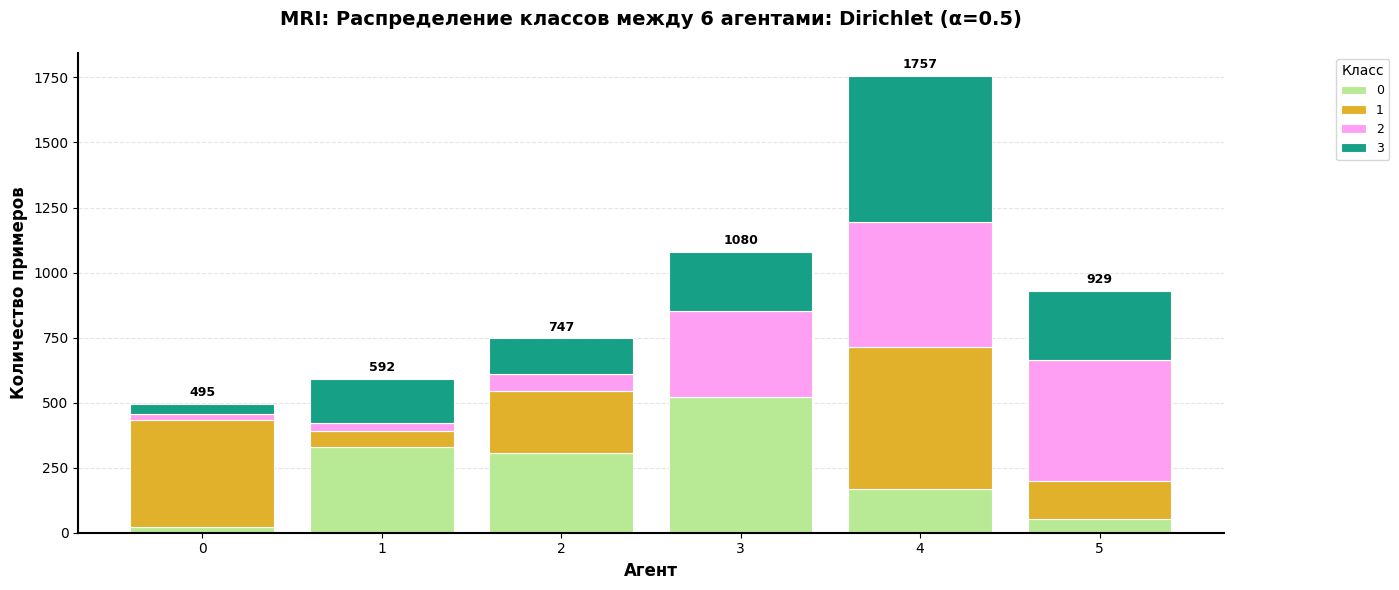

In [41]:
random.shuffle(colors)
visualize_agents_distribution(train_dataset, num_agents=6, distribution='dirichlet', colors=colors, title_prefix="MRI: ")

### Структура данных

Найдено классов: 4
Названия классов: ['glioma', 'meningioma', 'notumor', 'pituitary']


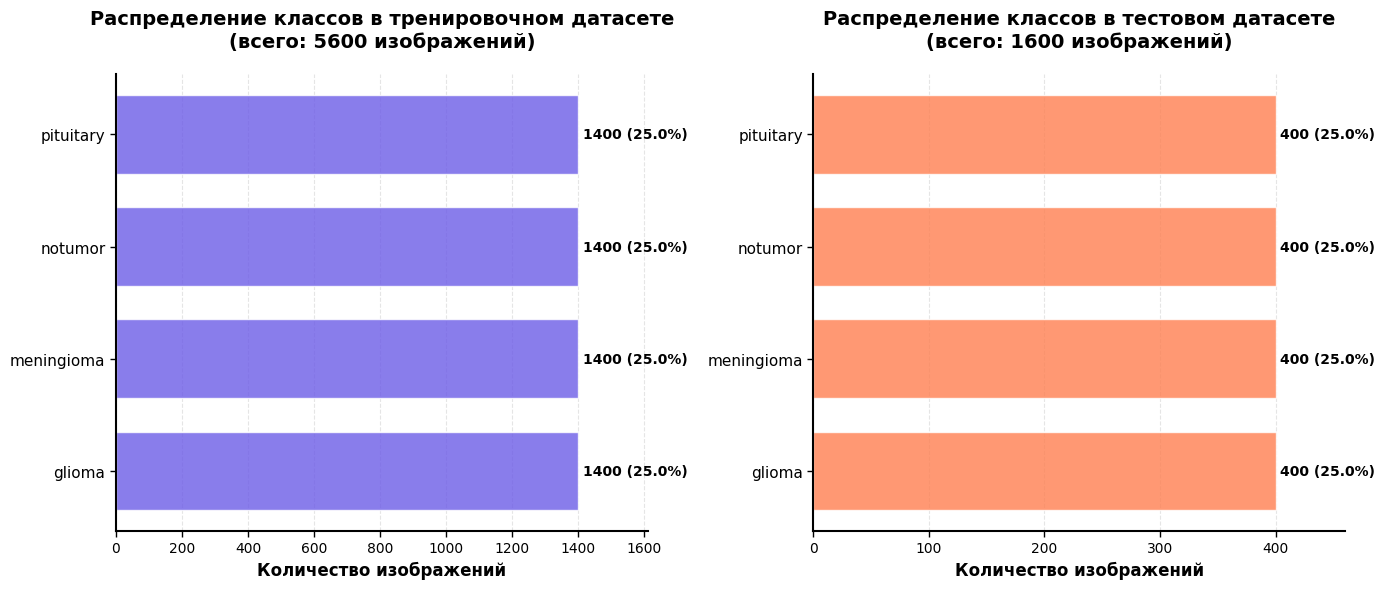

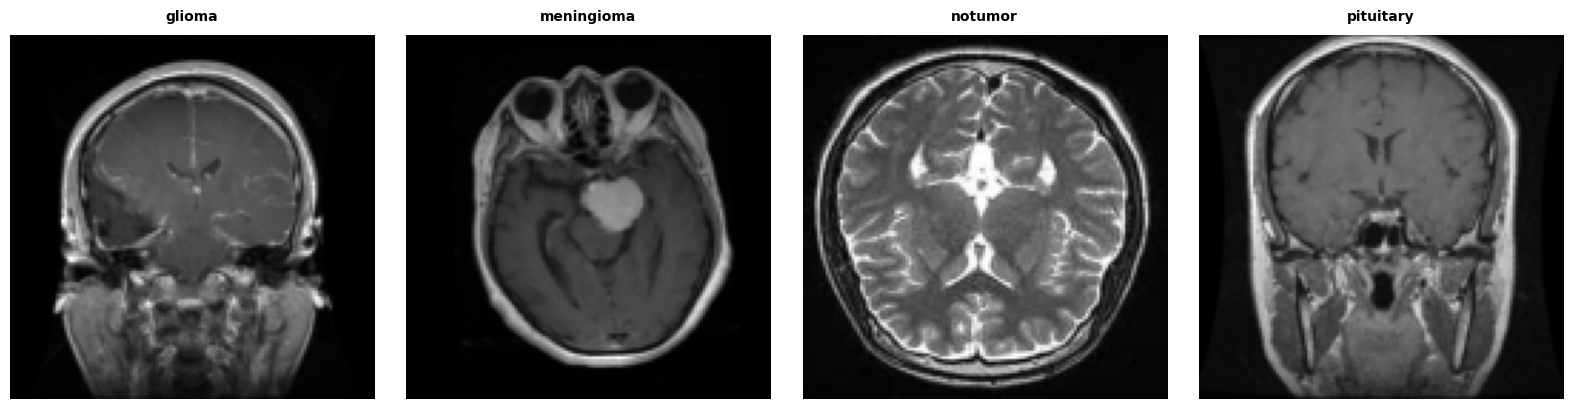


Соотношение (макс/мин): 1.00
Классы сбалансированы!


In [42]:
visualize_dataset_classes([random.choice(colors), random.choice(colors)], train_dataset, test_dataset, mean_val, std_val)

In [ ]:
N_RUNS = 5

base_config = {
    'packet_loss_rate': 0.0,
    'noise_std': 0.0,
    'node_dropout_prob': 0.0,
    'dropout_rounds_min': 1,
    'dropout_rounds_max': 5,
    'delay_min': 0,
    'delay_max': 0,
    'delay_probability': 0.0,
}

def make_config(name, **kwargs):
    config = base_config.copy()
    config['name'] = name
    config.update(kwargs)
    return config

network_configs = [
    make_config('ideal'),
    # make_config('loss_10', packet_loss_rate=0.1),
    # make_config('loss_30', packet_loss_rate=0.3),
    # make_config('loss_50', packet_loss_rate=0.5),
    # make_config('noise_0.005', noise_std=0.005),
    # make_config('noise_0.01', noise_std=0.01),
    # make_config('auto_dropout_10_stop_1-10', node_dropout_prob=0.1, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=True),
    # make_config('auto_dropout_10_continue_1-10', node_dropout_prob=0.1, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=False),
    # make_config('auto_dropout_30_stop_1-10', node_dropout_prob=0.3, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=True),
    # make_config('auto_dropout_30_continue_1-10', node_dropout_prob=0.3, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=False),
    # make_config('delay_1_5_0.1', delay_min=1, delay_max=5, delay_probability=0.1),
    # make_config('delay_1_5_0.3', delay_min=1, delay_max=5, delay_probability=0.3),
    # make_config('delay_6_10_0.1', delay_min=6, delay_max=10, delay_probability=0.1),
    # make_config('delay_6_10_0.3', delay_min=6, delay_max=10, delay_probability=0.3),
]

experiment_results = {cfg['name']: [] for cfg in network_configs}

for cfg in network_configs:
    config_name = cfg['name']
    
    for i in range(N_RUNS):
        seed = 4200 + i
        
        print(f"\n>>> Запуск {i+1}/{N_RUNS} (config={config_name}, seed={seed})")
        
        try:
            result = run_network_experiment(
                algorithm_key='dpsgd',
                num_rounds=200,
                train_dataset=train_dataset,
                test_dataset=test_dataset,
                packet_loss_rate=cfg['packet_loss_rate'],
                noise_std=cfg['noise_std'],
                node_dropout_prob=cfg['node_dropout_prob'],
                dropout_rounds_min=cfg['dropout_rounds_min'],
                dropout_rounds_max=cfg['dropout_rounds_max'],
                dropout_stops_training=cfg.get('dropout_stops_training', False),
                delay_min=cfg['delay_min'],
                delay_max=cfg['delay_max'],
                delay_probability=cfg['delay_probability'],
                scheduled_dropouts=cfg.get('scheduled_dropouts', None),
                verbose=True,
                global_model=TwoLayerNN,
                topology_key='mesh',
                random_seed=seed,
                num_agents=6,
                degree=2,
                return_all_metrics=True,
                distribution_type='iid',
                base_dir='results_MNIST',
                fix_learning_rate=False,
                initial_weights_flag=True,
                batch_size=64,
                learning_rate=0.01,
                coeff_lr=0.99
            )
            
            experiment_results[config_name].append(result)
            print(f"Acc={result['metric_dic']['accuracy'][-1]:.4f}")
            
        except Exception as e:
            print(f"Ошибка: {e}")
            experiment_results[config_name].append(None)

In [ ]:
N_RUNS = 5

base_config = {
    'packet_loss_rate': 0.0,
    'noise_std': 0.0,
    'node_dropout_prob': 0.0,
    'dropout_rounds_min': 1,
    'dropout_rounds_max': 5,
    'delay_min': 0,
    'delay_max': 0,
    'delay_probability': 0.0,
}

def make_config(name, **kwargs):
    config = base_config.copy()
    config['name'] = name
    config.update(kwargs)
    return config

network_configs = [
    # make_config('ideal'),
    # make_config('loss_10', packet_loss_rate=0.1),
    # make_config('loss_30', packet_loss_rate=0.3),
    # make_config('loss_50', packet_loss_rate=0.5),
    # make_config('noise_0.005', noise_std=0.005),
    make_config('noise_0.01', noise_std=0.01),
    # make_config('auto_dropout_10_stop_1-10', node_dropout_prob=0.1, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=True),
    # make_config('auto_dropout_10_continue_1-10', node_dropout_prob=0.1, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=False),
    # make_config('auto_dropout_30_stop_1-10', node_dropout_prob=0.3, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=True),
    # make_config('auto_dropout_30_continue_1-10', node_dropout_prob=0.3, dropout_rounds_min=1, dropout_rounds_max=10, dropout_stops_training=False),
    # make_config('delay_1_5_0.1', delay_min=1, delay_max=5, delay_probability=0.1),
    # make_config('delay_1_5_0.3', delay_min=1, delay_max=5, delay_probability=0.3),
    # make_config('delay_6_10_0.1', delay_min=6, delay_max=10, delay_probability=0.1),
    # make_config('delay_6_10_0.3', delay_min=6, delay_max=10, delay_probability=0.3),
]

experiment_results = {cfg['name']: [] for cfg in network_configs}

for cfg in network_configs:
    config_name = cfg['name']
    
    for i in range(N_RUNS):
        seed = 4200 + i
        
        print(f"\n>>> Запуск {i+1}/{N_RUNS} (config={config_name}, seed={seed})")
        
        try:
            result = run_network_experiment(
                algorithm_key='pame',
                num_rounds=200,
                train_dataset=train_dataset,
                test_dataset=test_dataset,
                packet_loss_rate=cfg['packet_loss_rate'],
                noise_std=cfg['noise_std'],
                node_dropout_prob=cfg['node_dropout_prob'],
                dropout_rounds_min=cfg['dropout_rounds_min'],
                dropout_rounds_max=cfg['dropout_rounds_max'],
                dropout_stops_training=cfg.get('dropout_stops_training', False),
                delay_min=cfg['delay_min'],
                delay_max=cfg['delay_max'],
                delay_probability=cfg['delay_probability'],
                scheduled_dropouts=cfg.get('scheduled_dropouts', None),
                verbose=True,
                global_model=TwoLayerNN,
                topology_key='mesh',
                random_seed=seed,
                num_agents=6,
                degree=2,
                return_all_metrics=True,
                distribution_type='iid',
                base_dir='results_MNIST',
                fix_learning_rate=False,
                initial_weights_flag=True,
                batch_size=64,
                sparsification_rate=0.2, 
                participation_rate=1, 
                sigma_0=20,
                gamma=1.005
            )
            
            experiment_results[config_name].append(result)
            print(f"Acc={result['metric_dic']['accuracy'][-1]:.4f}")
            
        except Exception as e:
            print(f"Ошибка: {e}")
            experiment_results[config_name].append(None)